In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**EDA**

In [4]:
df.shape

(1338, 7)

In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


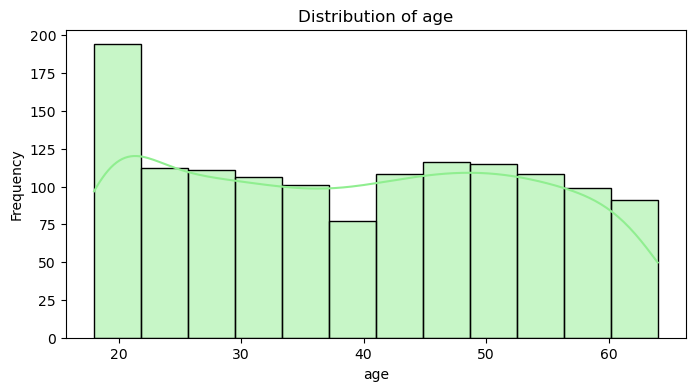

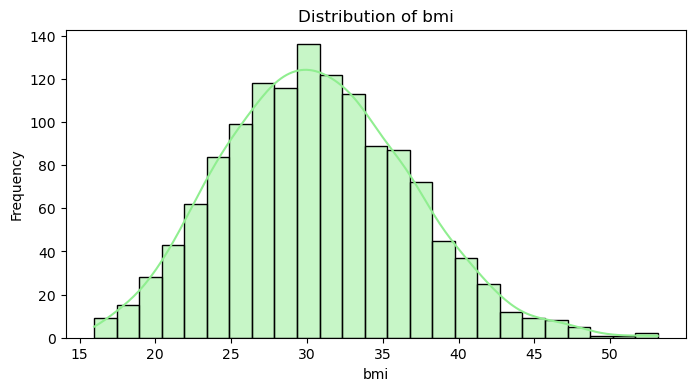

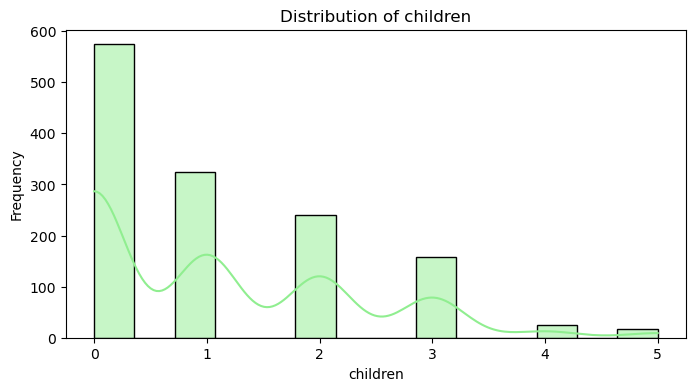

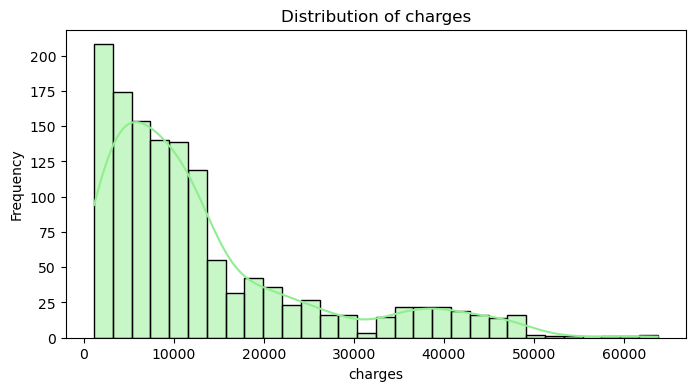

In [8]:
numeric_columns = ["age", "bmi", "children", "charges"]

for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, color="lightgreen" )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

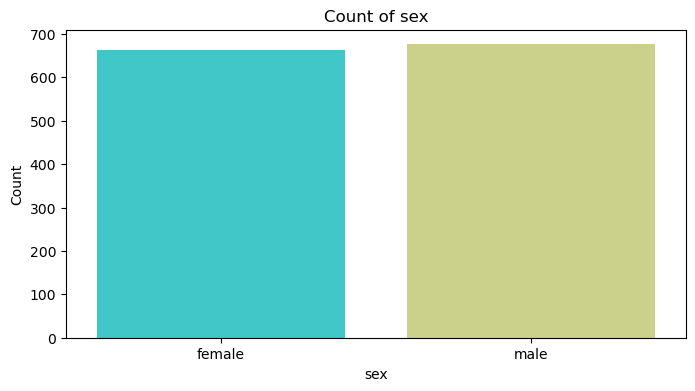

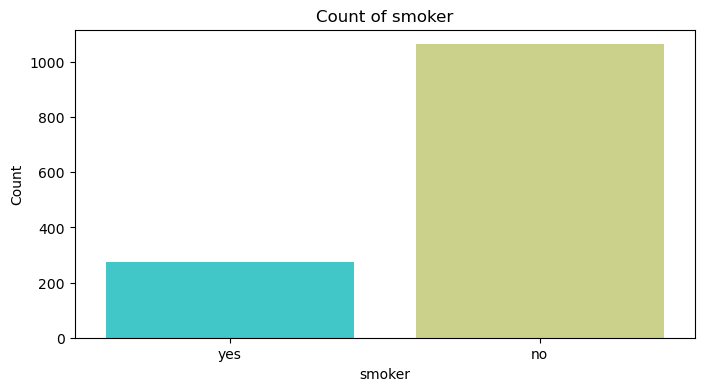

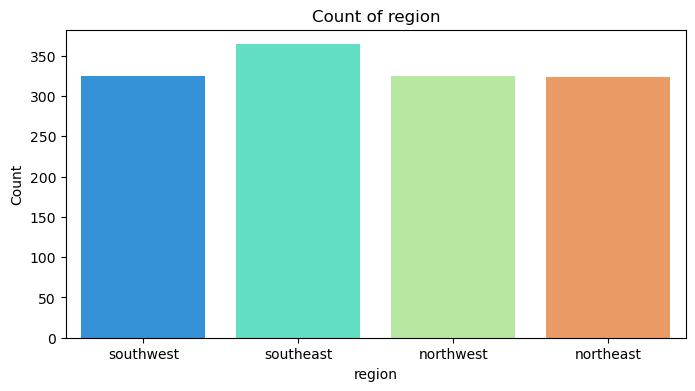

In [9]:
obj_column = ["sex","smoker","region"]

for col in obj_column:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col], palette="rainbow")
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

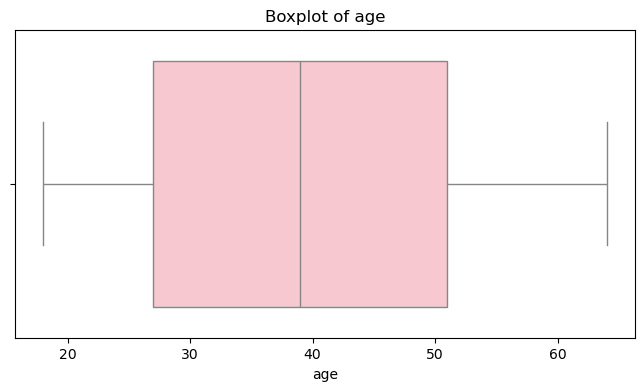

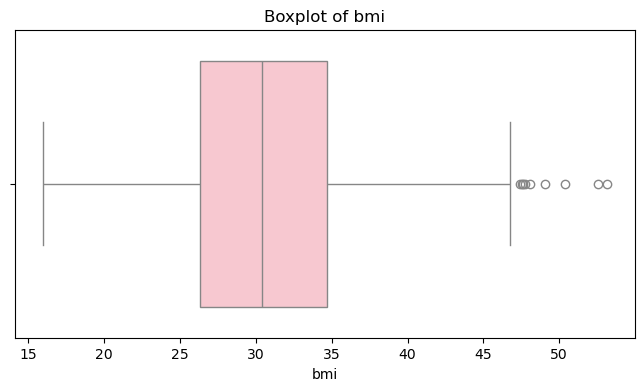

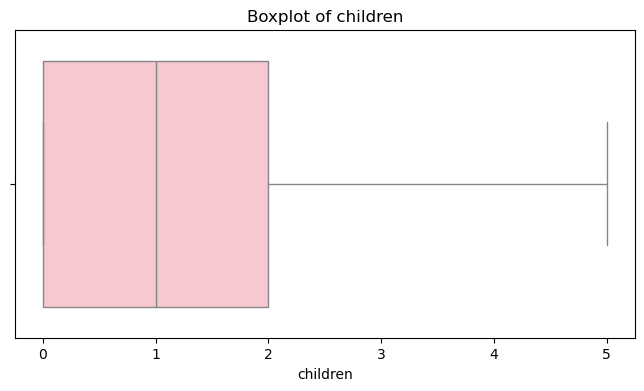

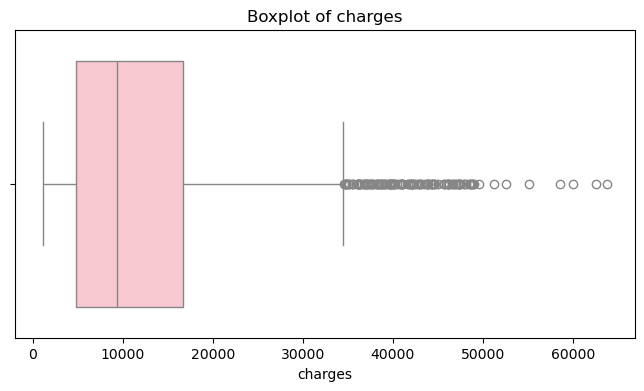

In [10]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color="pink")
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

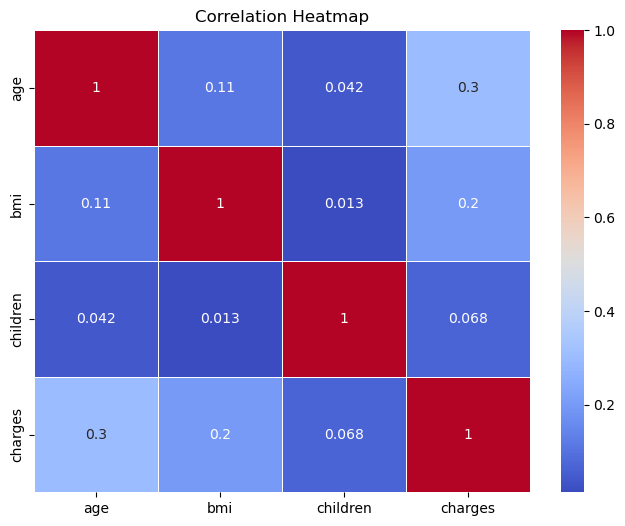

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True),annot =True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

**Data Cleanig and Preprocessing**

In [12]:
df_cleaned = df.copy()

In [13]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [14]:
df_cleaned.drop_duplicates(inplace=True)

In [15]:
df_cleaned.shape

(1337, 7)

In [16]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [17]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [18]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [19]:
df_cleaned["sex"] = df_cleaned["sex"].map({"male":0, "female":1})

In [20]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [21]:
df_cleaned["smoker"] = df_cleaned["smoker"].map({"no":0, "yes":1})

In [22]:
#df_cleaned["region"] = df_cleaned["region"].map({"northeast":0, "northwest":1, "southeast":2, "southwest":3})

In [23]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [24]:
df_cleaned.rename(columns={
    "sex": "is_female",
    "smoker": "is_smoker",
}, inplace=True)

In [25]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [26]:
df_cleaned = pd.get_dummies(df_cleaned, columns=["region"], drop_first=True)

In [27]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [28]:
df_cleaned = df_cleaned.astype(int)

In [29]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


**Feature Engineering and Extraction**

<Axes: xlabel='bmi', ylabel='Count'>

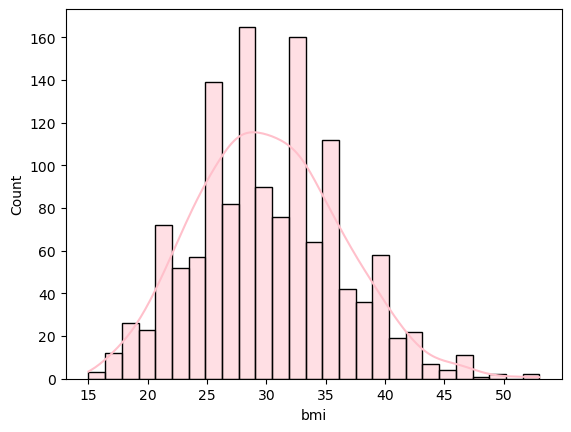

In [30]:
sns.histplot(df_cleaned["bmi"], kde=True, color="pink")

In [31]:
df_cleaned["bmi_category"] = pd.cut(df_cleaned["bmi"], bins=[0, 18.5, 25, 30, np.inf], labels=["Underweight", "Normal weight", "Overweight", "Obese"])

In [32]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal weight
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Overweight
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Normal weight


In [33]:
df_cleaned = pd.get_dummies(df_cleaned, columns=["bmi_category"], drop_first=True)

In [34]:
df_cleaned 

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,False,True,False
1334,18,1,31,0,0,2205,0,0,0,False,False,True
1335,18,1,36,0,0,1629,0,1,0,False,False,True
1336,21,1,25,0,0,2007,0,0,1,True,False,False


In [35]:
df_cleaned = df_cleaned.astype(int)

In [36]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal weight', 'bmi_category_Overweight',
       'bmi_category_Obese'],
      dtype='object')

In [37]:
from sklearn.preprocessing import StandardScaler
cols = ["age", "bmi", "children"]
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [38]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [39]:
from scipy.stats import pearsonr


selected_features = [
    "age","bmi","children","is_female","is_smoker","region_northwest","region_southeast","region_southwest",
    "bmi_category_Normal weight","bmi_category_Overweight","bmi_category_Obese"
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned["charges"])[0] 
    for feature in selected_features
}

correlation_df = pd.DataFrame(list(correlations.items()), columns=["Feature", "Pearson Correlation"])
correlation_df.sort_values(by="Pearson Correlation", ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
1,bmi,0.196236
10,bmi_category_Obese,0.189515
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046
9,bmi_category_Overweight,-0.081555


In [40]:
cat_features = [
    "is_female","is_smoker","region_northwest","region_southeast","region_southwest",
    "bmi_category_Normal weight","bmi_category_Overweight","bmi_category_Obese"
]



In [41]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned["charges_bin"] = pd.qcut(df_cleaned["charges"], q=4, labels=["Low", "Medium", "High", "Very High"])

chi2_results = {}

for col in cat_features:
    contingency_table = pd.crosstab(df_cleaned[col], df_cleaned["charges_bin"])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency_table)
    decision = "Reject Null Hypothesis" if p_val < alpha else "Accept Null (Drop Feature)"
    chi2_results[col] = {"chi2_statistic": chi2_stat, "p_value": p_val, "decision": decision}

chi2_df = pd.DataFrame(chi2_results).T
chi2_df.sort_values(by="p_value")
chi2_df    

,chi2_statistic,p_value,decision
is_female,10.258784,0.01649,Reject Null Hypothesis
is_smoker,848.219178,0.0,Reject Null Hypothesis
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)
region_southeast,15.998167,0.001135,Reject Null Hypothesis
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Normal weight,4.771699,0.189298,Accept Null (Drop Feature)
bmi_category_Overweight,4.450807,0.21672,Accept Null (Drop Feature)
bmi_category_Obese,9.737965,0.02093,Reject Null Hypothesis


In [42]:
final_df = df_cleaned[["age", "bmi", "children", "is_smoker", "charges","is_female", "region_northwest","region_southeast","region_southwest",
    "bmi_category_Normal weight","bmi_category_Overweight","bmi_category_Obese"]]

In [43]:
final_df

,age,bmi,children,is_smoker,charges,is_female,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,-0.517949,-0.909234,1,16884,1,0,0,1,0,1,0
1,-1.511647,0.462463,-0.079442,0,1725,0,0,1,0,0,0,1
2,-0.799350,0.462463,1.580143,0,4449,0,0,1,0,0,0,1
3,-0.443201,-1.334960,-0.909234,0,21984,0,1,0,0,1,0,0
4,-0.514431,-0.354547,-0.909234,0,3866,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,-0.027743,1.580143,0,10600,0,1,0,0,0,1,0
1334,-1.511647,0.135659,-0.909234,0,2205,1,0,0,0,0,0,1
1335,-1.511647,0.952670,-0.909234,0,1629,1,0,1,0,0,0,1
1336,-1.297958,-0.844753,-0.909234,0,2007,1,0,0,1,1,0,0
